# HDC Variants Comparison Demo

Purpose: compare several compact HDC variants under the same subject-wise validation setting.

This is a P1 demonstration of the planned comparison logic, not the final optimized HDC experiment.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"E:/hdc-vr-pilot")
TEST_DIR = ROOT / "test"
sys.path.insert(0, str(TEST_DIR))

from hdc_demo_utils import (
    HDCConfig,
    MultiCentroidHDC,
    OnlineHDStyleHDC,
    VanillaPrototypeHDC,
    evaluate_hdc_models,
    get_feature_columns,
    load_phase03_dataset,
    select_top_variance_features,
)

RESULTS = TEST_DIR / "results"
FIGURES = TEST_DIR / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)


In [2]:
df = load_phase03_dataset()
all_features = get_feature_columns(df)
selected_features = select_top_variance_features(df[all_features], max_features=300)

X = df[selected_features]
y = df["target"].astype(int).to_numpy()
groups = df["subject_id"].astype(str).to_numpy()

print("Selected feature count for HDC demo:", len(selected_features))
print("Validation: subject-wise GroupKFold")


Selected feature count for HDC demo: 300
Validation: subject-wise GroupKFold


In [3]:
base_config = HDCConfig(dimensions=1000, n_levels=21, random_state=42)
models = {
    "Vanilla Prototype HDC": VanillaPrototypeHDC(base_config),
    "OnlineHD-style HDC": OnlineHDStyleHDC(base_config, epochs=1, learning_rate=1.0),
    "Multi-centroid HDC": MultiCentroidHDC(base_config, centroids_per_class=2),
    "HDC+OnlineHD Hybrid": OnlineHDStyleHDC(base_config, epochs=2, learning_rate=0.5),
}

fold_metrics, summary, confusion = evaluate_hdc_models(X, y, groups, models, n_splits=5)
display(summary)
fold_metrics.to_csv(RESULTS / "hdc_variants_fold_metrics.csv", index=False)
summary.to_csv(RESULTS / "hdc_variants_summary.csv", index=False)


D:\Computer\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Computer\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a mem

C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\76176\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,fit_predict_seconds_mean,fit_predict_seconds_std
1,Multi-centroid HDC,0.646816,0.051277,0.646991,0.051196,0.643807,0.052464,0.643862,0.052696,0.441425,0.122236
0,HDC+OnlineHD Hybrid,0.634796,0.040545,0.635530,0.039929,0.619939,0.044151,0.619230,0.044882,0.473247,0.002869
3,Vanilla Prototype HDC,0.594378,0.024696,0.595087,0.024420,0.594614,0.026202,0.594173,0.026777,0.266066,0.003037
2,OnlineHD-style HDC,0.522834,0.081879,0.522565,0.082695,0.486402,0.093214,0.486512,0.092368,0.469210,0.005225


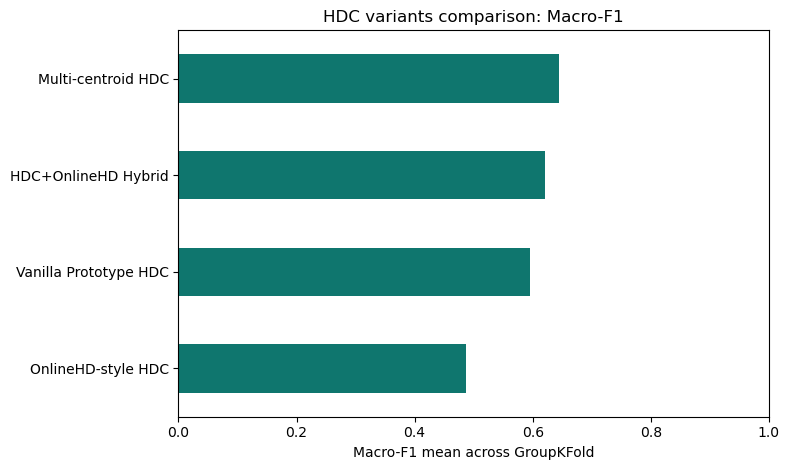

Best preliminary HDC variant by mean Macro-F1: Multi-centroid HDC


,pred_0,pred_1,pred_2,pred_3
true_0,65,19,8,12
true_1,20,54,24,8
true_2,3,17,67,17
true_3,2,1,17,85


In [4]:
plot_df = summary.sort_values("macro_f1_mean", ascending=True)
ax = plot_df.plot(x="model", y="macro_f1_mean", kind="barh", legend=False, figsize=(8, 4.8), color="#0f766e")
ax.set_title("HDC variants comparison: Macro-F1")
ax.set_xlabel("Macro-F1 mean across GroupKFold")
ax.set_xlim(0, 1)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES / "hdc_variants_macro_f1_comparison.png", dpi=160)
plt.show()

best_model = summary.iloc[0]["model"]
print("Best preliminary HDC variant by mean Macro-F1:", best_model)
cm_df = pd.DataFrame(confusion[best_model], index=["true_0", "true_1", "true_2", "true_3"], columns=["pred_0", "pred_1", "pred_2", "pred_3"])
cm_df.to_csv(RESULTS / "hdc_variants_best_confusion_matrix.csv")
display(cm_df)


## Interpretation for P1 defense

The notebook demonstrates how the final HDC phase can compare multiple design choices under one validation protocol.
The current result should be presented as a compact feasibility comparison, not as the final selected model.
